## Tabular Models — Seattle Airbnb price prediction

Four models in increasing complexity:

| # | Model | Encoding |
|---|---|---|
| 1 | Dummy (mean) | — |
| 2 | Ridge (RidgeCV) | OHE + TargetEnc(neighbourhood) + StandardScaler |
| 3 | Random Forest | OrdinalEncoder |
| 4 | LightGBM | Native categoricals |

Target: `log_price = log(price)` from `data/raw/target.csv` (Person B).  
Features: `data/processed/tabular_train.csv` / `tabular_test.csv` (52 cols, 0 NaNs).

## Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

from src.tabular.model import (
    train_dummy, train_ridge, train_rf, train_lgbm, evaluate
)

## Load data and target

In [3]:
X_train = pd.read_csv("../data/processed/tabular_train.csv")
X_test  = pd.read_csv("../data/processed/tabular_test.csv")
target  = pd.read_csv("../data/raw/target.csv")

tgt     = target.set_index("id")["log_price"]
y_train = X_train["id"].map(tgt)
y_test  = X_test["id"].map(tgt)

# Drop any rows missing a target (shouldn't happen with valid split files)
mask_tr = y_train.notna()
mask_te = y_test.notna()
if not mask_tr.all() or not mask_te.all():
    print(f"Dropping {(~mask_tr).sum()} train / {(~mask_te).sum()} test rows (missing target)")
    X_train = X_train[mask_tr].reset_index(drop=True)
    y_train = y_train[mask_tr].reset_index(drop=True)
    X_test  = X_test[mask_te].reset_index(drop=True)
    y_test  = y_test[mask_te].reset_index(drop=True)

print(f"Train : {len(X_train):,} rows")
print(f"Test  : {len(X_test):,} rows")
print(f"Target: log_price in [{y_train.min():.2f}, {y_train.max():.2f}]  "
      f"(median {y_train.median():.2f})")

Train : 4,926 rows
Test  : 1,232 rows
Target: log_price in [2.71, 7.45]  (median 4.99)


## 1. Dummy baseline

In [4]:
dummy = train_dummy(X_train, y_train)

dummy_tr = evaluate(y_train, dummy.predict(X_train), "dummy  train")
dummy_te = evaluate(y_test,  dummy.predict(X_test),  "dummy  test ")

[dummy  train]          RMSE log=0.5791   RMSE $=       135
[dummy  test ]          RMSE log=0.5780   RMSE $=       139


## 2. Ridge (RidgeCV)

In [5]:
ridge = train_ridge(X_train, y_train)
print(f"Best alpha (LOO-CV): {ridge['model'].alpha_:.1f}")

ridge_tr = evaluate(y_train, ridge.predict(X_train), "ridge  train")
ridge_te = evaluate(y_test,  ridge.predict(X_test),  "ridge  test ")

Best alpha (LOO-CV): 1.0
[ridge  train]          RMSE log=0.2818   RMSE $=        97
[ridge  test ]          RMSE log=0.3102   RMSE $=        97


## 3. Random Forest

In [6]:
rf = train_rf(X_train, y_train)

rf_tr = evaluate(y_train, rf.predict(X_train), "rf     train")
rf_te = evaluate(y_test,  rf.predict(X_test),  "rf     test ")

[rf     train]          RMSE log=0.2013   RMSE $=        71
[rf     test ]          RMSE log=0.2933   RMSE $=        96


## 4. LightGBM

In [7]:
lgbm = train_lgbm(X_train, y_train)

lgbm_tr = evaluate(y_train, lgbm.predict(X_train), "lgbm   train")
lgbm_te = evaluate(y_test,  lgbm.predict(X_test),  "lgbm   test ")

[lgbm   train]          RMSE log=0.0330   RMSE $=        20
[lgbm   test ]          RMSE log=0.2119   RMSE $=        76


## Results summary

In [9]:
rows = [
    ("Dummy",        dummy_tr,  dummy_te),
    ("Ridge",        ridge_tr,  ridge_te),
    ("RandomForest", rf_tr,     rf_te),
    ("LightGBM",     lgbm_tr,   lgbm_te),
]

summary = pd.DataFrame([
    {
        "model":           name,
        "train RMSE (log)": tr["rmse_log"],
        "test RMSE (log)":  te["rmse_log"],
        "train RMSE ($)":   tr["rmse_dollar"],
        "test RMSE ($)":    te["rmse_dollar"],
    }
    for name, tr, te in rows
]).set_index("model")

summary.style.format({
    "train RMSE (log)": "{:.4f}",
    "test RMSE (log)":  "{:.4f}",
    "train RMSE ($)":   "${:,.0f}",
    "test RMSE ($)":    "${:,.0f}",
}).highlight_min(axis=0, color="#c6efce")

,train RMSE (log),test RMSE (log),train RMSE ($),test RMSE ($)
model,,,,
Dummy,0.5791,0.5780,$135,$139
Ridge,0.2818,0.3102,$97,$97
RandomForest,0.2013,0.2933,$71,$96
LightGBM,0.0330,0.2119,$20,$76


## Test RMSE comparison (bar chart)

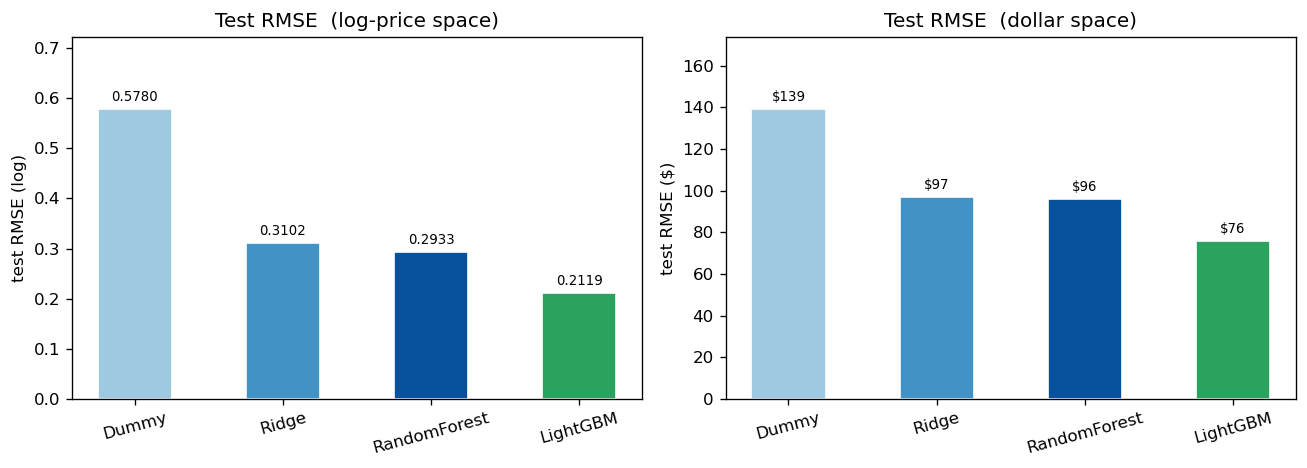

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models = summary.index.tolist()
colors = ["#9ecae1", "#4292c6", "#08519c", "#2ca25f"]

for ax, col, title in zip(
    axes,
    ["test RMSE (log)", "test RMSE ($)"],
    ["Test RMSE  (log-price space)", "Test RMSE  (dollar space)"],
):
    vals = summary[col].values
    bars = ax.bar(models, vals, color=colors, edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt=("%.4f" if "log" in col else "$%.0f"), fontsize=8, padding=3)
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Feature importances

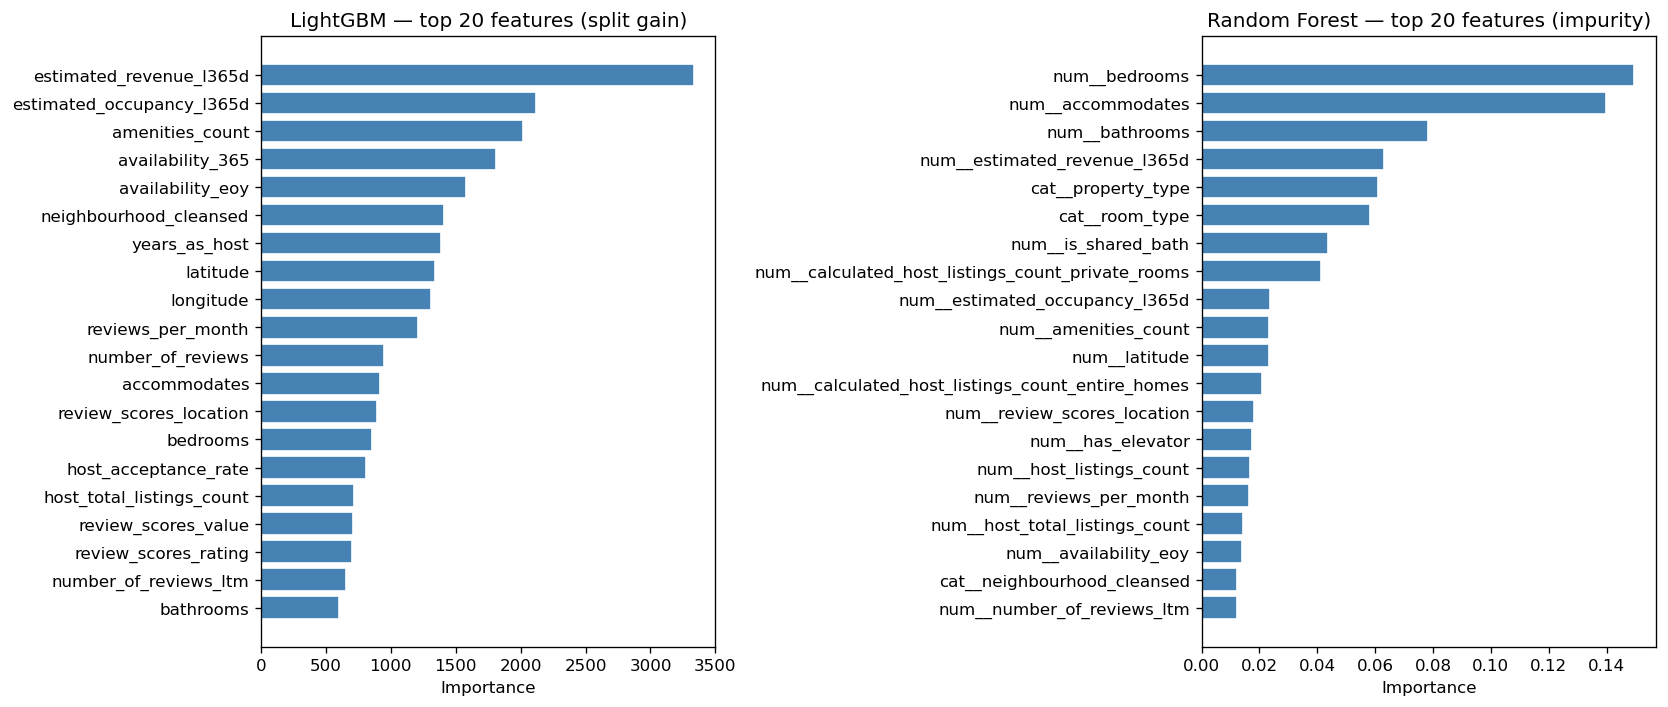

In [11]:
# ── LightGBM importances ───────────────────────────────────────────────────────
lgbm_imp = (
    pd.Series(lgbm.feature_importances_, index=lgbm.feature_name_)
    .sort_values(ascending=False)
    .head(20)
)

# ── Random Forest importances ─────────────────────────────────────────────────
rf_feature_names = rf["ct"].get_feature_names_out().tolist()
rf_imp = (
    pd.Series(rf["model"].feature_importances_, index=rf_feature_names)
    .sort_values(ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, imp, title in zip(
    axes,
    [lgbm_imp, rf_imp],
    ["LightGBM — top 20 features (split gain)",
     "Random Forest — top 20 features (impurity)"],
):
    ax.barh(imp.index[::-1], imp.values[::-1], color="steelblue", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## Residual analysis — LightGBM (test set)

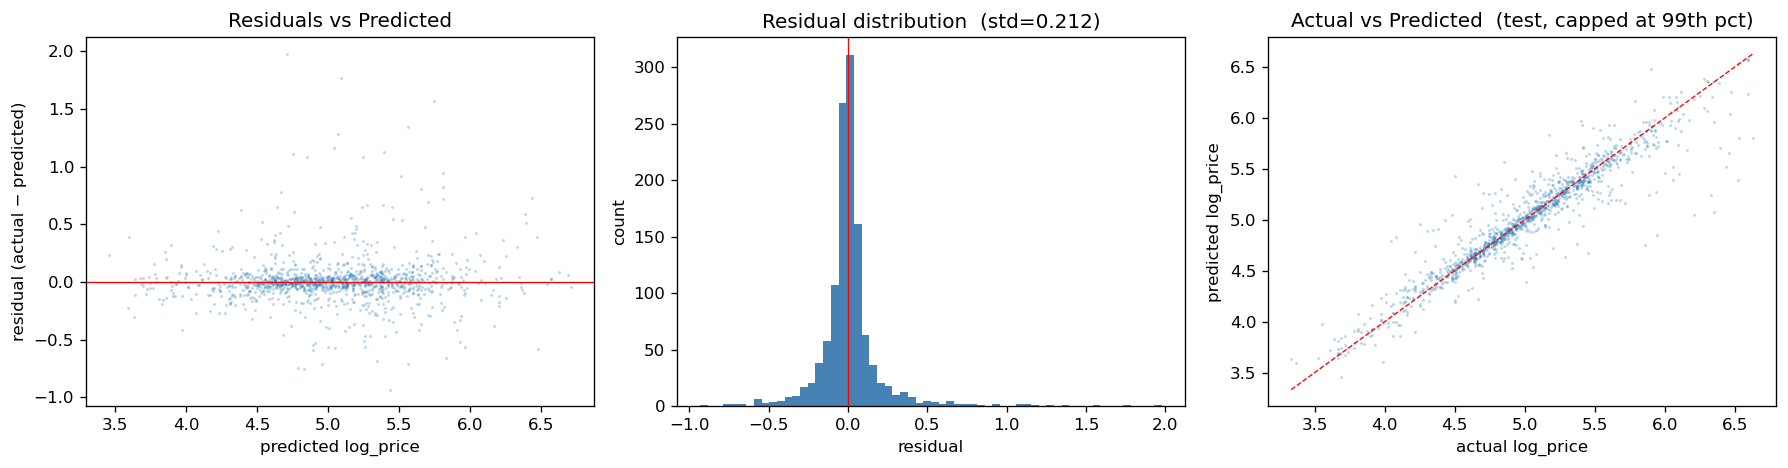

In [12]:
y_pred_te = lgbm.predict(X_test)
residuals  = y_test.values - y_pred_te

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_te, residuals, s=3, alpha=0.3, linewidths=0)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_xlabel("predicted log_price")
axes[0].set_ylabel("residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

# Residual distribution
axes[1].hist(residuals, bins=60, edgecolor="none", color="steelblue")
axes[1].axvline(0, color="red", linewidth=0.8)
axes[1].set_xlabel("residual")
axes[1].set_ylabel("count")
axes[1].set_title(f"Residual distribution  (std={residuals.std():.3f})")

# Actual vs predicted (capped at 99th pct for visual clarity)
cap = np.percentile(y_test.values, 99)
mask = y_test.values <= cap
axes[2].scatter(y_test.values[mask], y_pred_te[mask], s=3, alpha=0.3, linewidths=0)
lims = [y_test.values[mask].min(), cap]
axes[2].plot(lims, lims, "r--", linewidth=0.8)
axes[2].set_xlabel("actual log_price")
axes[2].set_ylabel("predicted log_price")
axes[2].set_title("Actual vs Predicted  (test, capped at 99th pct)")

plt.tight_layout()
plt.show()

## Residuals by room type

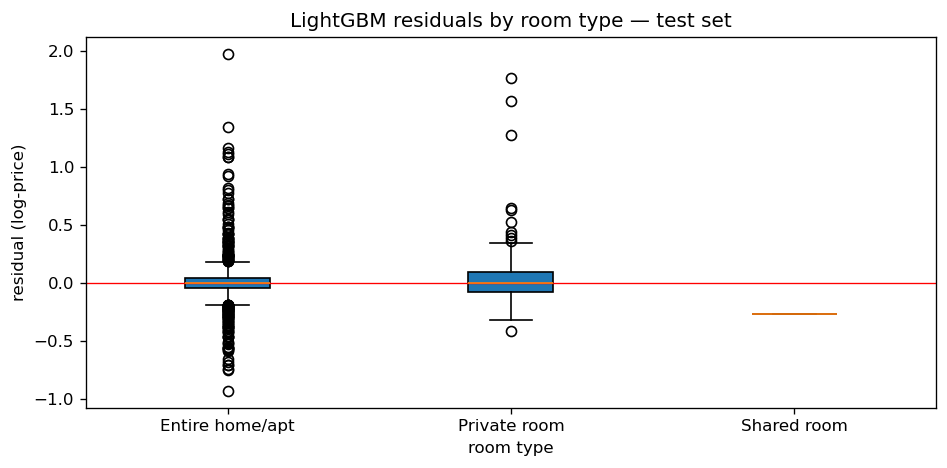

Median residual by room type:
  Entire home/apt       n=1047  median=-0.002  std=0.202
  Private room          n= 184  median=-0.000  std=0.254
  Shared room           n=   1  median=-0.267  std=0.000


In [13]:
room_types = X_test["room_type"].values
unique_rooms = sorted(set(room_types))
data_by_room = [residuals[room_types == rt] for rt in unique_rooms]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data_by_room, tick_labels=unique_rooms, patch_artist=True)
ax.axhline(0, color="red", linewidth=0.8)
ax.set_xlabel("room type")
ax.set_ylabel("residual (log-price)")
ax.set_title("LightGBM residuals by room type — test set")
plt.tight_layout()
plt.show()

print("Median residual by room type:")
for rt, d in zip(unique_rooms, data_by_room):
    print(f"  {rt:<20}  n={len(d):>4}  median={np.median(d):+.3f}  std={d.std():.3f}")

## Ridge coefficients (top 20 by absolute value)

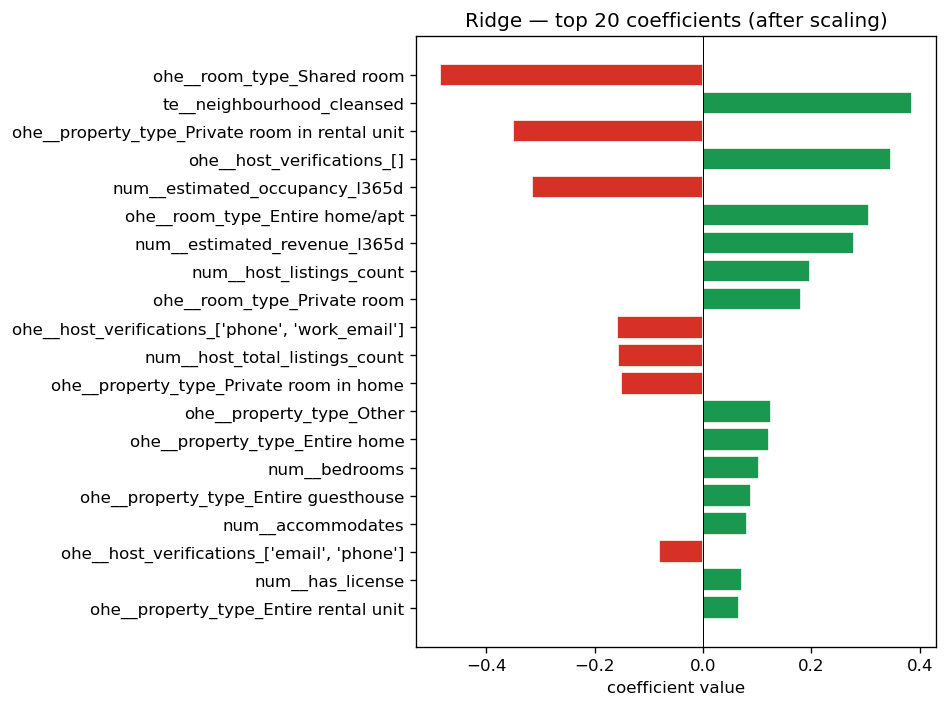

In [14]:
ridge_names = ridge["ct"].get_feature_names_out().tolist()
ridge_coefs = pd.Series(
    ridge["model"].coef_, index=ridge_names
).reindex(pd.Series(ridge["model"].coef_, index=ridge_names).abs().sort_values(ascending=False).index)

top = ridge_coefs.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
colors_coef = ["#d73027" if v < 0 else "#1a9850" for v in top.values[::-1]]
ax.barh(top.index[::-1], top.values[::-1], color=colors_coef, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_title("Ridge — top 20 coefficients (after scaling)")
ax.set_xlabel("coefficient value")
plt.tight_layout()
plt.show()

## Save LightGBM predictions

In [15]:
from pathlib import Path
out = Path("../data/processed")

pd.DataFrame({
    "id":             X_test["id"].values,
    "log_price_pred": lgbm.predict(X_test),
}).to_csv(out / "tabular_preds_test.csv", index=False)

pd.DataFrame({
    "id":             X_train["id"].values,
    "log_price_pred": lgbm.predict(X_train),
}).to_csv(out / "tabular_preds_train.csv", index=False)

print(f"Saved tabular_preds_test.csv  ({len(X_test):,} rows)")
print(f"Saved tabular_preds_train.csv ({len(X_train):,} rows)")

Saved tabular_preds_test.csv  (1,232 rows)
Saved tabular_preds_train.csv (4,926 rows)
